Progression of preprocessing:
- Cropped to AOI (within intersection of image bounds)
- Coregistered
- Pansharpened (ms only)

In [29]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
from shapely import Polygon

# coastsat modules
sys.path.insert(0, os.pardir)
from coastsat import SDS_download, SDS_preprocess, SDS_shoreline, SDS_tools, SDS_classify, SDS_transects
from osgeo import gdal
gdal.UseExceptions()

from indices import *
from thresholding import *
from spectral_plotting import plot_extractions
import wv_utils as wv
import modified_coastsat

# paths
base_dir = "C:\\Users\\avanever\\Documents\\Imagery Datasets\\WV3 SWIR\\W075_N10\\20200104T15431"
swir_fn = os.path.join(base_dir, "20JAN04154316-A3DS-015384188020_01_P001.TIF")
ms_fn = os.path.join(base_dir, "20JAN04154317-M3DS-015384188010_01_P001.TIF")
pan_fn = os.path.join(base_dir, "20JAN04154317-P3DS-015384188010_01_P001.TIF")
ref_sl_path = Path(r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\colombia_hand_digitized\colombia_hand_shoreline.shp")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Run Preprocessing

takes a few minutes, larger AOI may run into memory allocation issues (pansharpening). Running functions one at a time may allow for larger AOI (gives garbage collection to catch up maybe?)

Produces high resolution pansharpened image and degraded image

Note: rerunning may cause issues with already having files open

In [ ]:
# prepare AOI in world coordinates (for Colombia WV3 image)
aoi = np.array([[3500, 2400], # bigger (pushing it)
                [3500, 4000],
                [500, 4000],
                [500, 2400],
                [3500, 2400]])

# aoi = np.array([[2500, 2500], # smaller
#                 [2500, 3500],
#                 [1250, 3500],
#                 [1250, 2500],
#                 [2500, 2500]])
ms = gdal.Open(ms_fn, gdal.GA_ReadOnly)
gt = ms.GetGeoTransform()
aoi_world = np.array([[gt[0] + x * gt[1], gt[3] + y * gt[5]] for x, y in aoi])

array([[ 443424., 1152132.],
       [ 443424., 1150212.],
       [ 439824., 1150212.],
       [ 439824., 1152132.],
       [ 443424., 1152132.]])

In [ ]:
# both pipelines require cropping
wv.crop_tifs(swir_fn, pan_fn, ms_fn, aoi_world, base_dir)

# high res
wv.coreg_tifs(base_dir, gdal.GRA_Average) # coregister different bands together (ms, swir, pan)
wv.pansharpen(base_dir)

# low res
target_res = 10
swir_deg_fn, ms_deg_fn = wv.naive_degradation(target_res, gdal.GRA_Bilinear, base_dir)
sim_fn = wv.naive_band_smushing(ms_deg_fn, swir_deg_fn, base_dir)

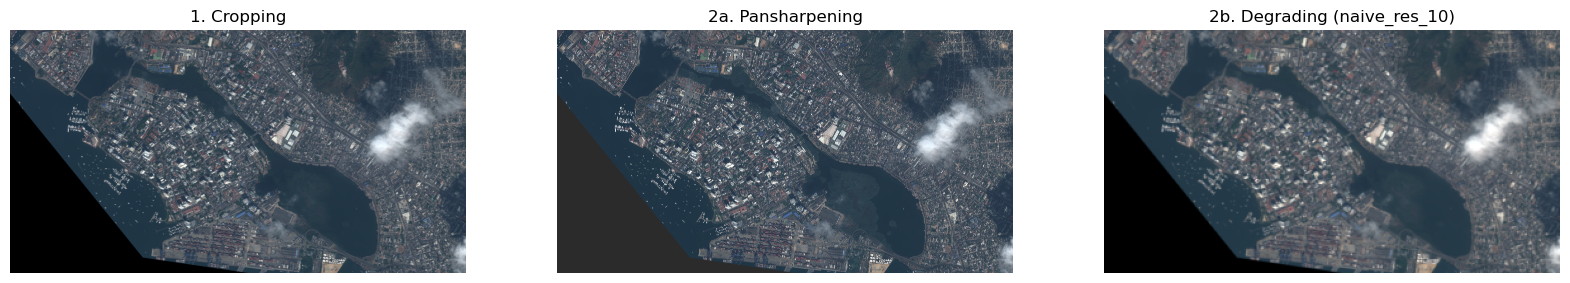

In [24]:
deg_type = f"naive_res_{target_res}"
wv.plot_preprocessing_steps(base_dir, deg_type)

# Individual Steps

## EDA

In [2]:
ms_bands = wv.load_tif(ms_fn)
print(f"{ms_bands.shape = }")

# pan_bands = load_tif(pan_fn)
# print(f"{pan_bands.shape = }")

# swir_bands = load_tif(swir_fn, is_swir=True)
# print(f"{swir_bands.shape = }")

ms_bands.shape = (11490, 6865, 8)


In [3]:
y_dim = 2000
y_start = 200
x_dim = 3000
x_start = 0

bands = wv.crop(ms_bands, x_start, x_dim, y_start, y_dim)
bands.shape

(2000, 3000, 8)

In [4]:
cloud_mask = np.zeros(bands.shape[:-1], dtype=bool)

Text(0.5, 1.0, '[4, 2, 1]')

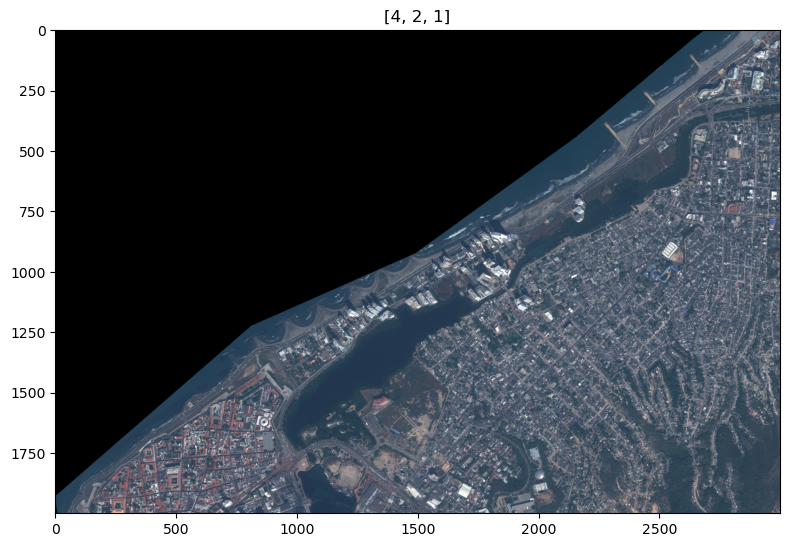

In [5]:
idx_comb = [4, 2, 1] # RGB
fig, ax = plt.subplots(1, 1, figsize=(8, 12), tight_layout=True)
im_adj = SDS_preprocess.rescale_image_intensity(bands[:,:,idx_comb], cloud_mask, 99.9)
ax.imshow(im_adj)
ax.set_title(str(idx_comb))

## Cropping

In [30]:
aoi = np.array([[3500, 2400],
                [3500, 4000],
                [500, 4000],
                [500, 2400],
                [3500, 2400]])

aoi = np.array([[2500, 2500],
                [2500, 3500],
                [1250, 3500],
                [1250, 2500],
                [2500, 2500]])


ms = gdal.Open(ms_fn, gdal.GA_ReadOnly)
gt = ms.GetGeoTransform()
aoi_world = np.array([[gt[0] + x * gt[1], gt[3] + y * gt[5]] for x, y in aoi])

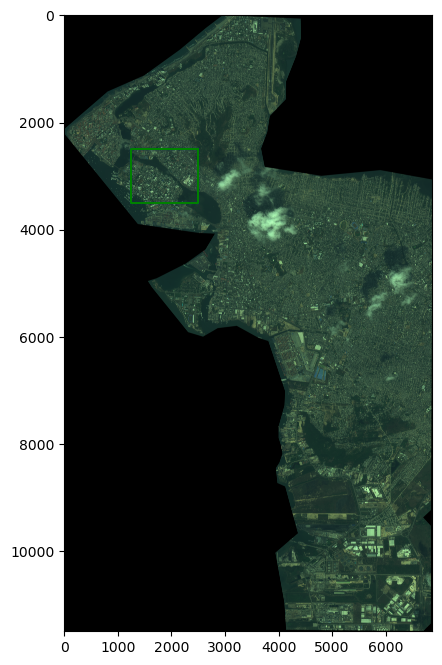

In [7]:
aoi_pix = SDS_tools.convert_world2pix(aoi_world, ms.GetGeoTransform())
ms_bands = wv.load_tif(ms_fn)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(ms_bands[:,:,[4, 2, 1]])
ax.plot(aoi[:,0], aoi[:,1], c="blue")
ax.plot(aoi_pix[:,0], aoi_pix[:,1], c="green")

In [32]:
crop_swir_fn, crop_pan_fn, crop_ms_fn = wv.crop_tifs(swir_fn, pan_fn, ms_fn, aoi_world, base_dir)

(323, 407, 8)


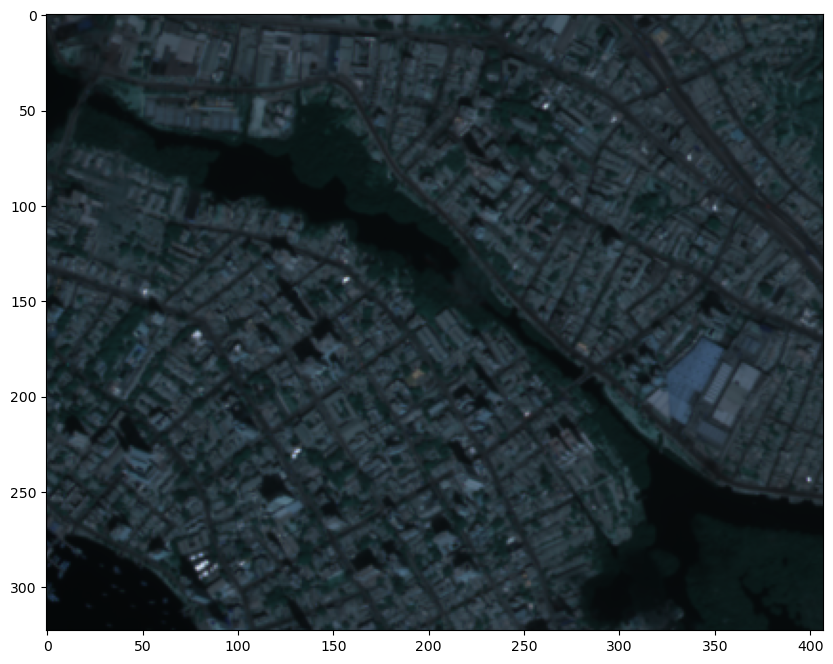

In [9]:
crop_bands = wv.load_tif(crop_swir_fn, is_swir=True)
print(crop_bands.shape)
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(crop_bands[:,:,[4, 2, 1]])
# ax.imshow(crop_bands) # for pan

## Coregistration

In [ ]:
coreg_swir_fn, coreg_pan_fn, coreg_ms_fn = wv.coreg_tifs(base_dir, gdal.GRA_Average)

In [12]:
# sanity check (values should all be the same)
for fn in [coreg_swir_fn, coreg_ms_fn, coreg_pan_fn]:
    ds = gdal.Open(fn)
    gt = ds.GetGeoTransform()
    f = fn.split("\\")[-1]
    print(f"{f}: size=({ds.RasterXSize}, {ds.RasterYSize}), origin=({gt[0]:.2f}, {gt[3]:.2f}), res=({gt[1]}, {gt[5]})")

swir_cropped.tif: size=(5000, 4000), origin=(440724.00, 1152012.00), res=(0.3, -0.3)
ms_cropped.tif: size=(5000, 4000), origin=(440724.00, 1152012.00), res=(0.3, -0.3)
pan_cropped.tif: size=(5000, 4000), origin=(440724.00, 1152012.00), res=(0.3, -0.3)


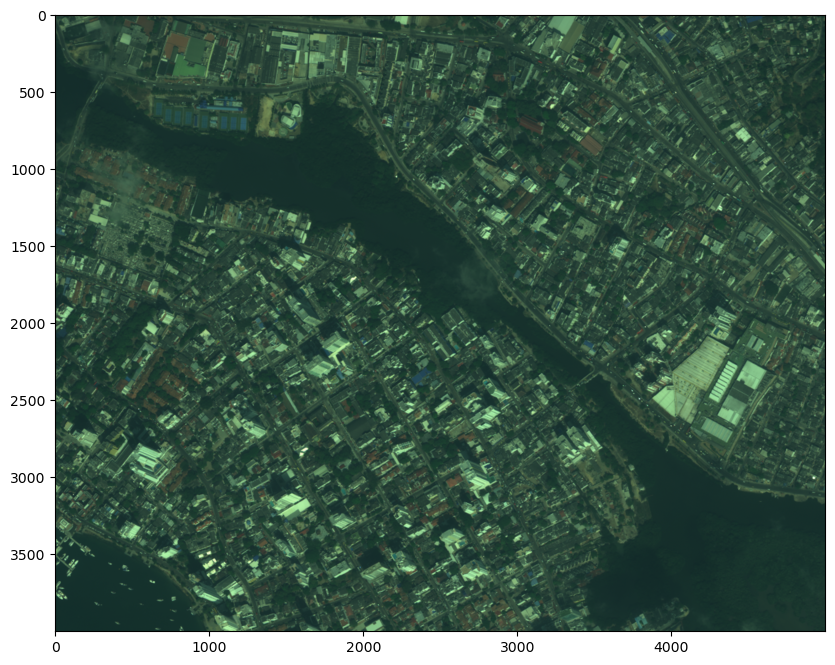

In [13]:
crop_bands = wv.load_tif(coreg_ms_fn, is_swir=False)
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(crop_bands[:,:,[4, 2, 1]])
# ax.imshow(crop_bands) # for pan

## Pansharpening

panchromatic band covers 450-800nm. This covers blue, green, yellow, red, and red edge. NIR1 covers 770-895nm which partially overlaps, but is excluded here.

In [ ]:
ps_ms_fn = wv.pansharpen(base_dir)

ps_bands.shape = (6400, 12000, 8)


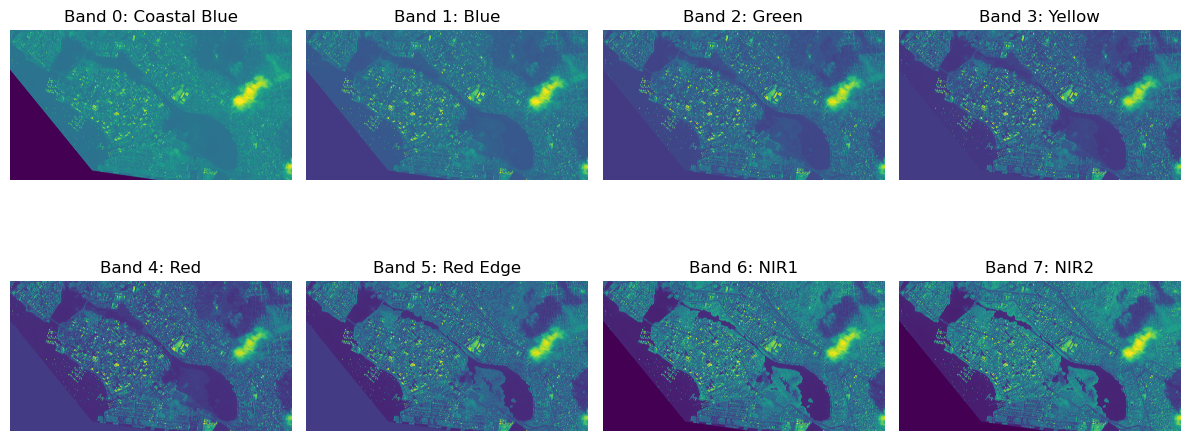

In [12]:
ps_ms_fn = wv.get_ps_tif_name(base_dir)
ps_bands = wv.load_tif(ps_ms_fn, is_swir=False)
cloud_mask = np.zeros(ps_bands.shape[:-1], dtype=bool)
print(f"{ps_bands.shape = }")

wv.plot_bands(ps_bands, ps_bands.shape[-1], cloud_mask)

coreg_bands.shape = (4000, 5000, 8)


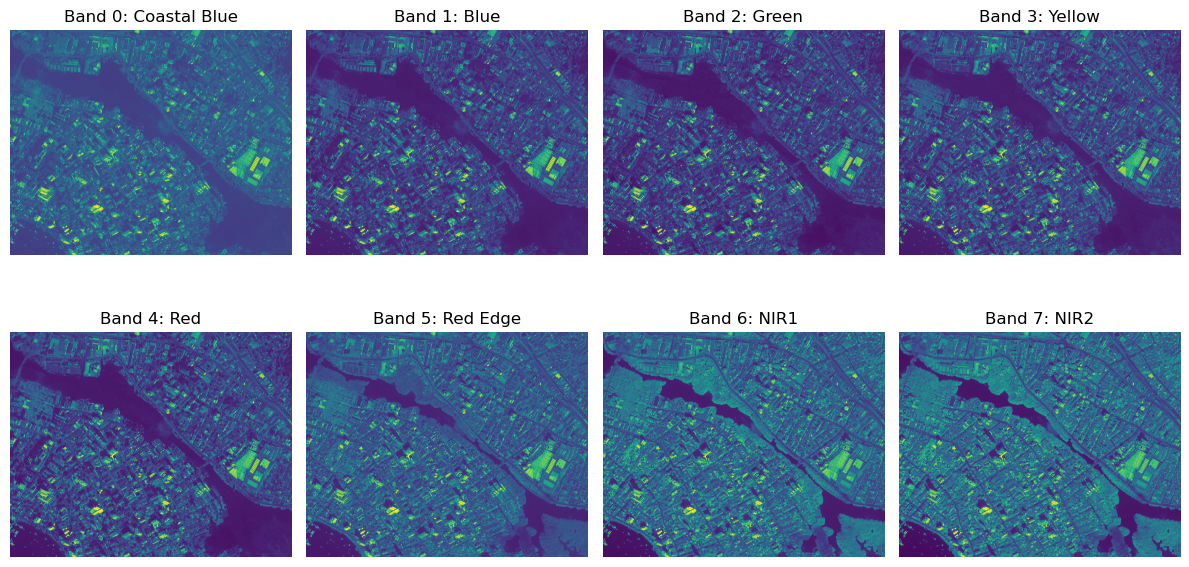

In [10]:
coreg_ms_fn = wv.get_coreg_tif_name("ms", base_dir)
coreg_bands = wv.load_tif(coreg_ms_fn, is_swir=False)
cloud_mask = np.zeros(coreg_bands.shape[:-1], dtype=bool)
print(f"{coreg_bands.shape = }")

wv.plot_bands(coreg_bands, coreg_bands.shape[-1], cloud_mask)

## High Res Automated Shoreline Extraction

In [12]:
def ndwi_from_ms(bands):
    green = bands[:,:,2]
    nir = bands[:,:,6]
    return (green - nir) / (nir + green)

coreg_ms_fn = wv.get_coreg_tif_name("ms", base_dir)
coreg_bands = wv.load_tif(coreg_ms_fn, is_swir=False)

In [24]:
ndwi_im = ndwi_from_ms(coreg_bands)
ndwi_no_nan = ndwi_im[~np.isnan(ndwi_im)]
otsu_t = filters.threshold_otsu(ndwi_no_nan.ravel())
contours = measure.find_contours(ndwi_im, otsu_t)

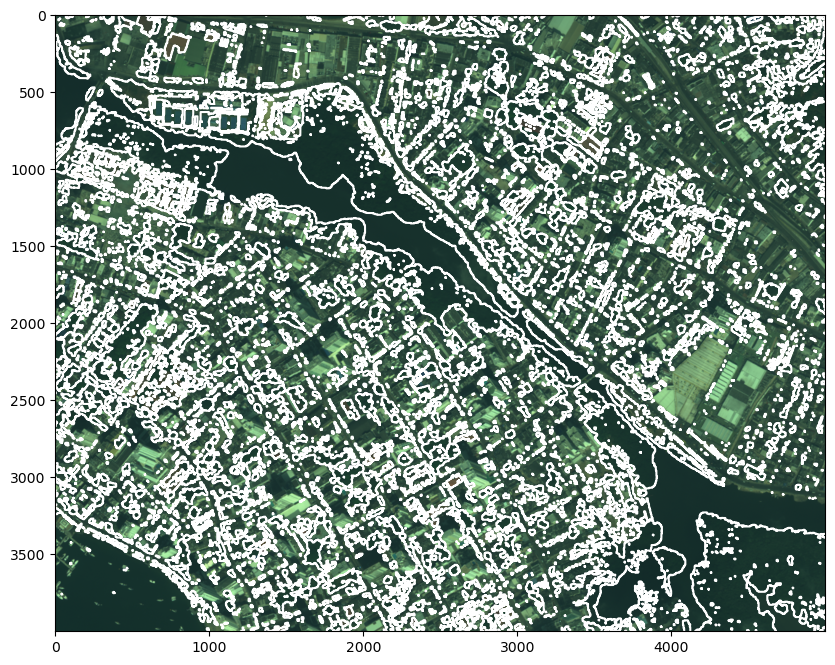

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(coreg_bands[:,:,[4, 2, 1]])
for contour in contours:
    ax.plot(contour[:,1], contour[:,0], c="white")

well darn

## Hand-Digitized Shoreline

In [15]:
ms_fn = wv.get_coreg_tif_name("ms", base_dir)
ms = gdal.Open(ms_fn)

ref_sl_list, ref_sl_pxl_list = wv.load_ref_sl(ref_sl_path, ms.GetGeoTransform())
ms_bands = wv.load_tif(ms_fn)

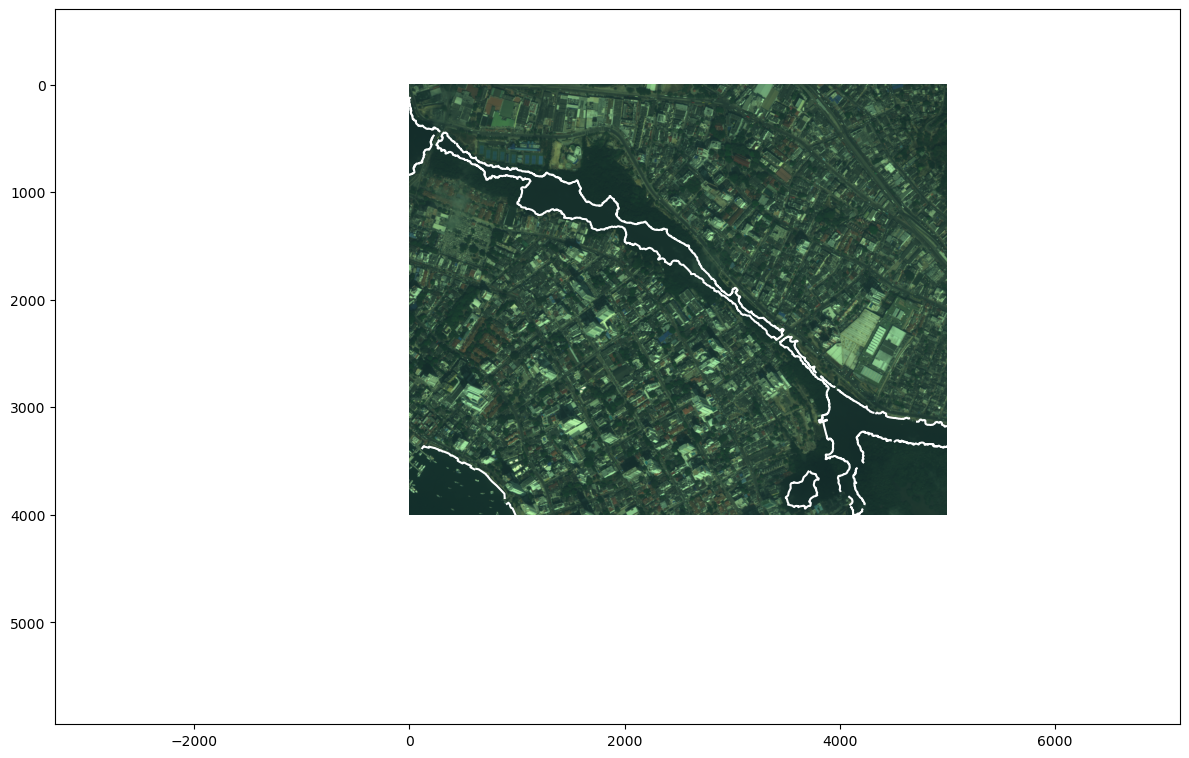

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8), tight_layout=True)
ax.imshow(ms_bands[:,:, [4, 2, 1]])

for line_px in ref_sl_pxl_list:
    ax.plot(line_px[:,0], line_px[:,1], c="white")

plt.show()
plt.close(fig)

## Degrading Imagery

In [18]:
swir_deg_fn, ms_deg_fn = wv.naive_degradation(10, gdal.GRA_Bilinear, base_dir)
sim_fn = wv.naive_band_smushing(ms_deg_fn, swir_deg_fn, base_dir)

In [19]:
# sanity check (values should all be the same)
for fn in [swir_deg_fn, ms_deg_fn]:
    ds = gdal.Open(fn)
    gt = ds.GetGeoTransform()
    f = fn.split("\\")[-1]
    print(f"{f}: size=({ds.RasterXSize}, {ds.RasterYSize}), origin=({gt[0]:.2f}, {gt[3]:.2f}), res=({gt[1]}, {gt[5]})")

swir_degraded.tif: size=(151, 120), origin=(440721.80, 1152009.80), res=(10.0, -10.0)
ms_degraded.tif: size=(151, 120), origin=(440721.80, 1152009.80), res=(10.0, -10.0)


(120, 151, 6)


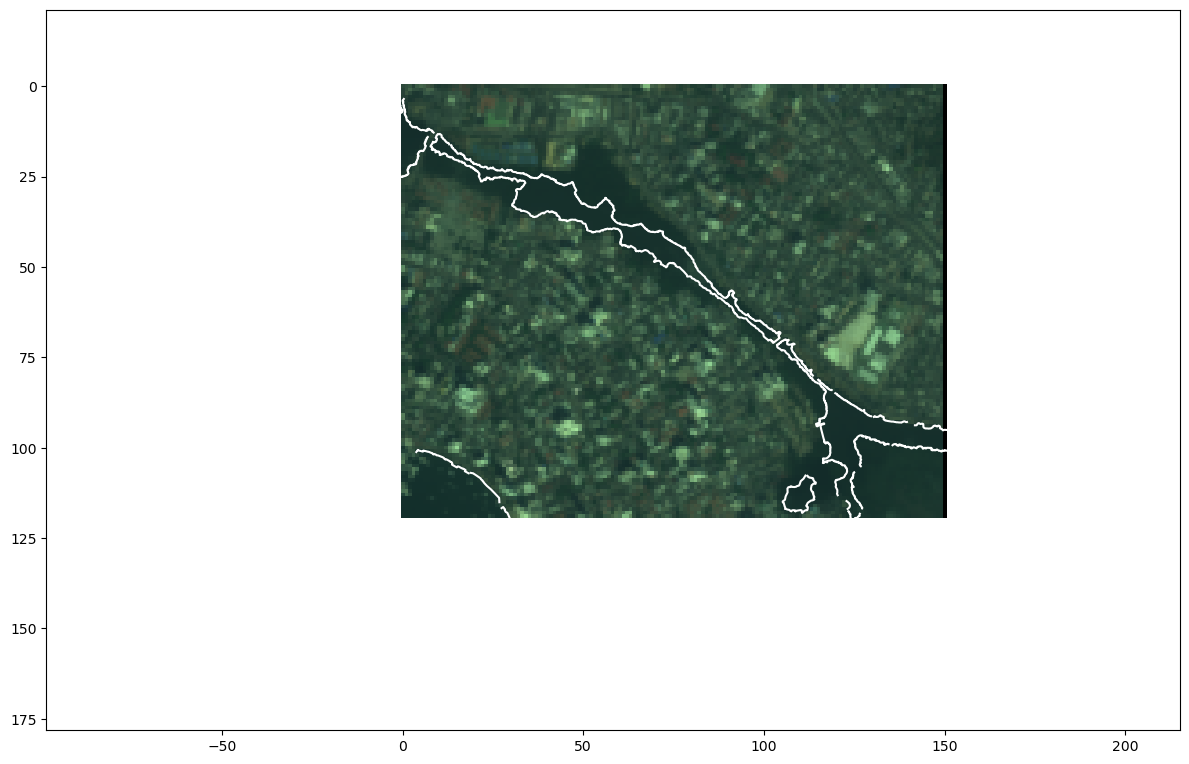

In [6]:
sim_bands = wv.load_sim_tif(sim_fn)
print(sim_bands.shape)

fig, axs = plt.subplots(1, 1, figsize=(12, 8), tight_layout=True)
axs.imshow(sim_bands[:,:,[2, 1, 0]])

sim = gdal.Open(sim_fn)
ref_sl_list, ref_sl_pxl_list = wv.load_ref_sl(ref_sl_path, sim.GetGeoTransform())
for line_px in ref_sl_pxl_list:
    axs.plot(line_px[:,0], line_px[:,1], c="white")

## Applying Shoreline Extraction

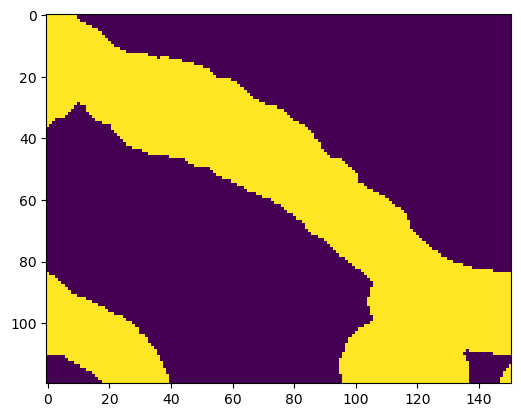

In [3]:
sim_fn = wv.get_sim_tif_name("naive_res_10", base_dir)
sim_bands = wv.load_sim_tif(sim_fn)
sim = gdal.Open(sim_fn)

ref_sl_list, ref_sl_pxl_list = wv.load_ref_sl(ref_sl_path, sim.GetGeoTransform())
sl_buffer = wv.create_shoreline_buffer(sim_bands.shape[:-1], ref_sl_pxl_list, 10)

fig, ax = plt.subplots(1, 1)
ax.imshow(sl_buffer)

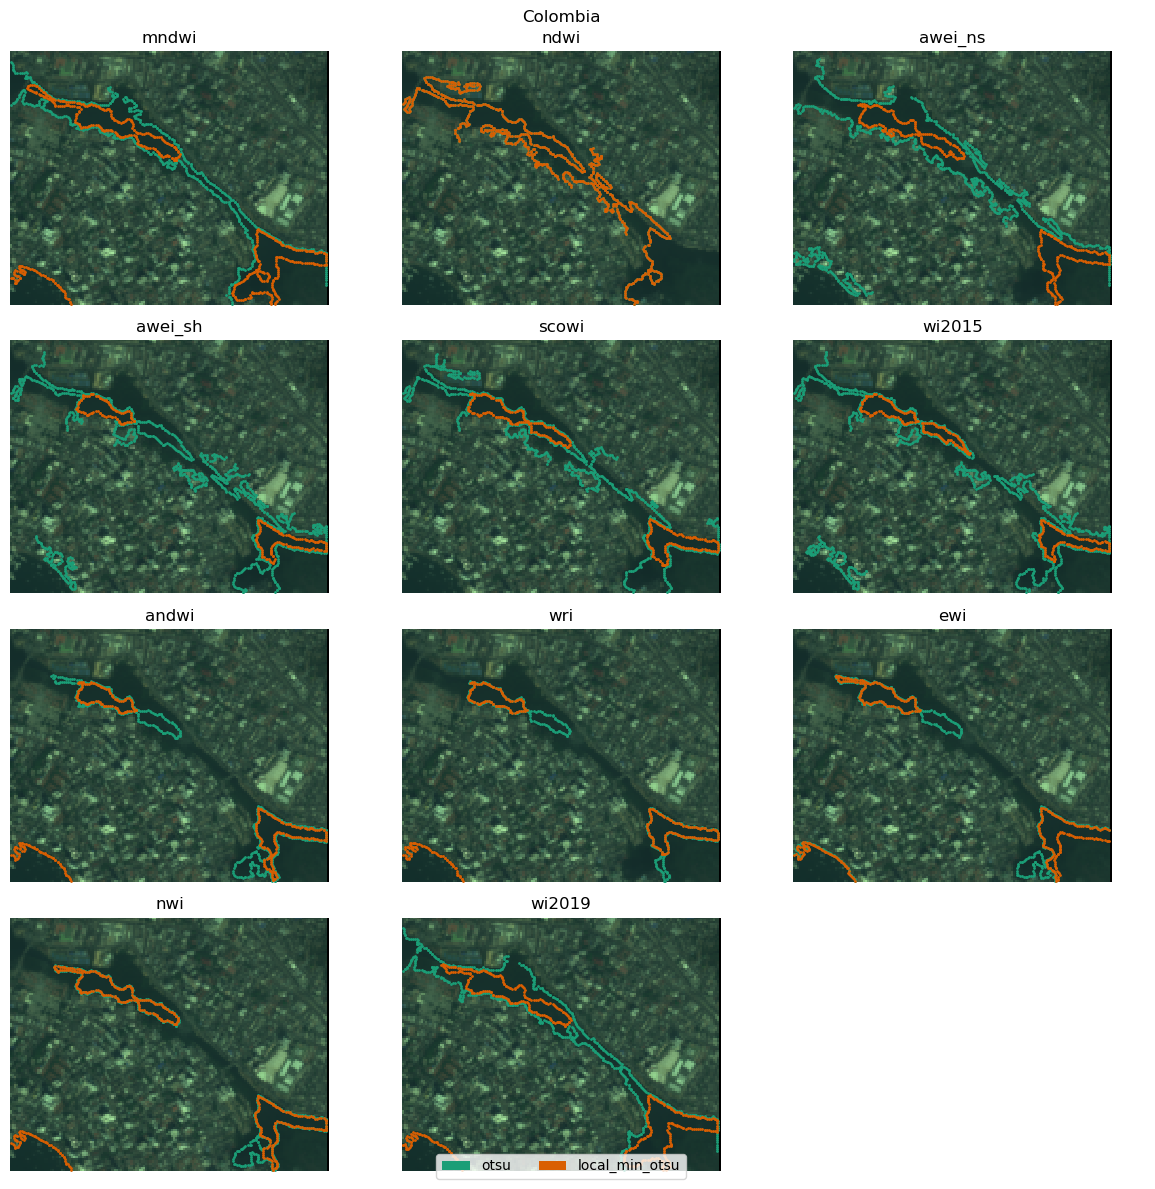

In [4]:
cloud_mask = np.full(sim_bands.shape[:-1], False)
settings = {
    'output_epsg': 4326,
    'max_dist_ref': 400,
    'min_length_sl': 500,
    'dist_clouds': 30,
}

index_functions = [
    mndwi,
    ndwi,
    awei_ns,
    awei_sh,
    scowi,
    wi2015,
    andwi,
    wri,
    ewi,
    nwi,
    wi2019
]
threshold_functions = [
    otsu,
    local_min_otsu
]
plot_extractions(
    sim_bands,
    "Colombia",
    index_functions,
    threshold_functions,
    cloud_mask,
    sl_buffer,
    cloud_mask,
    sim.GetGeoTransform(),
    4326,
    settings,
    rescale=False
)